In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print (tf.__version__)


2.19.0


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
train = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_test.csv")

print(train.shape)
print(test.shape)

(27455, 785)
(7172, 785)


In [46]:
x_train_full = train.drop('label', axis = 1).values
y_train_full = train['label'].values

x_test = test.drop('label', axis = 1).values
y_test = test['label'].values

x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full,
    test_size = 0.2, random_state = 42, stratify = y_train_full)

num_classes = 25
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

class_names = [chr (i) for i in range (65,91) if chr(i) not in ('J', 'Z')]

print(f"Train: {x_train.shape[0]} | valid: {x_valid.shape[0]} | test: {x_test.shape[0]}")
print("Classes:", class_names)

Train: 21964 | valid: 5491 | test: 7172
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


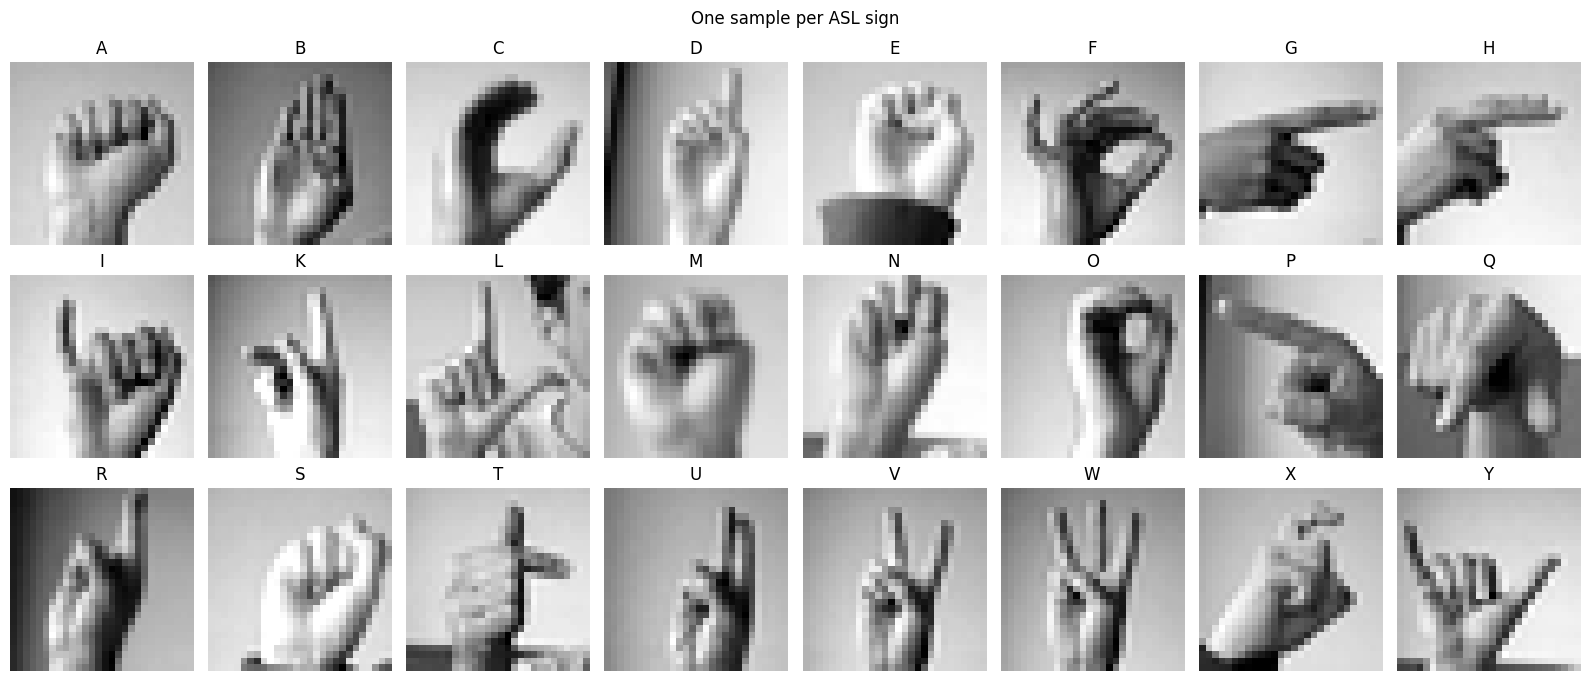

In [47]:
unique_labels = np.unique(y_train.argmax(axis = 1))

fig, axes = plt.subplots(3, 8, figsize = (16, 7))
axes = axes.flatten()

for i, class_name_char in enumerate(class_names):
  # Determine the actual numeric label value corresponding to the i-th class_name
  actual_label_value = i
  if i >= 9: # Account for the skipped 'J' (label 9)
    actual_label_value += 1

  sample = np.where(y_train.argmax(axis = 1) == actual_label_value)[0][0]
  axes[i].imshow(x_train[sample].squeeze(), cmap = 'gray')
  axes[i].set_title(class_name_char)
  axes[i].axis('off')

plt.suptitle("One sample per ASL sign")
plt.tight_layout()
plt.show()

In [48]:
model_baseline = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax')
])

model_baseline.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,577 (1.62 MB)

 Trainable params: 423,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_1r = 1e-6)
]

start = time.time()

history_baseline = model_baseline.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 1
)

baseline_time = round(time.time() - start)
print(f"Training time: {baseline_time} seconds")

Epoch 1/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3284 - loss: 2.1551 - val_accuracy: 0.8141 - val_loss: 0.7293 - learning_rate: 0.0010
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6686 - loss: 0.9687 - val_accuracy: 0.9375 - val_loss: 0.3063 - learning_rate: 0.0010
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7652 - loss: 0.6539 - val_accuracy: 0.9428 - val_loss: 0.1862 - learning_rate: 0.0010
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8166 - loss: 0.5037 - val_accuracy: 0.9902 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8528 - loss: 0.3997 - val_accuracy: 0.9954 - val_loss: 0.0439 - learning_rate: 0.0010
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8687 - loss: 0.3559 - val_accuracy: 0.9978 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8817 - loss: 0.3135 -

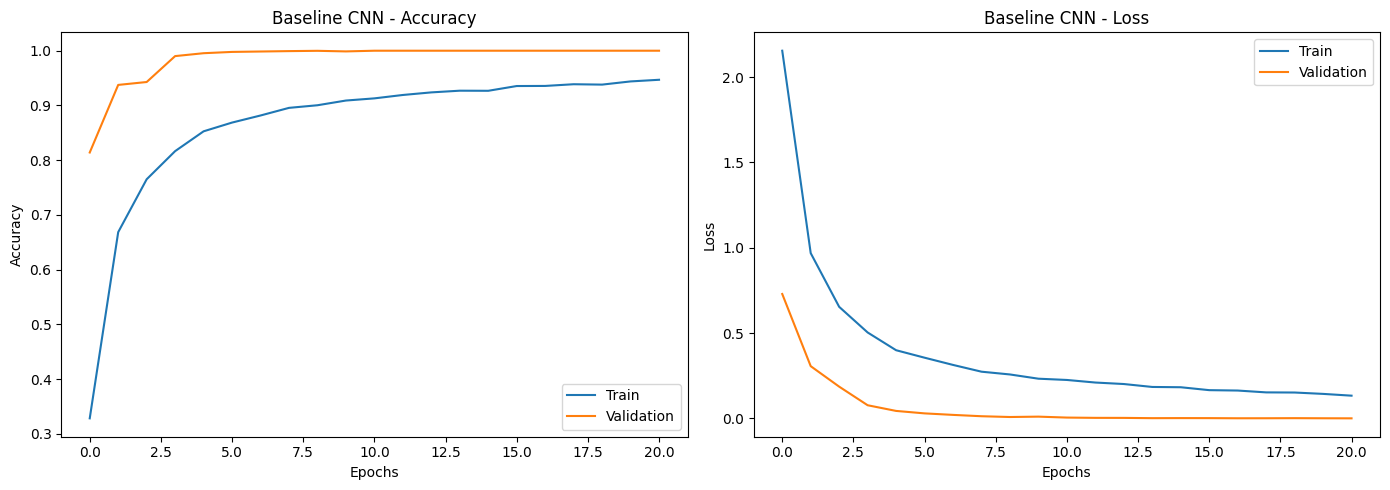

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(history_baseline.history['accuracy'], label = 'Train')
ax1.plot(history_baseline.history['val_accuracy'], label = 'Validation')
ax1.set_title('Baseline CNN - Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_baseline.history['loss'], label = 'Train')
ax2.plot(history_baseline.history['val_loss'], label = 'Validation')
ax2.set_title('Baseline CNN - Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [51]:
model_enhanced = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1 )),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 438,585 (1.67 MB)

 Trainable params: 437,561 (1.67 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [52]:
fresh_callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

model_enhanced = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

start = time.time()
history_enhanced = model_enhanced.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 64,
    callbacks = fresh_callbacks,
    verbose = 1
)

enhanced_time = round(time.time() - start)
print(f"Training time: {enhanced_time} seconds")


Epoch 1/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.7360 - loss: 0.8634 - val_accuracy: 0.0758 - val_loss: 7.5354 - learning_rate: 0.0010
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9875 - loss: 0.0457 - val_accuracy: 0.9975 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9958 - loss: 0.0168 - val_accuracy: 0.9998 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9940 - loss: 0.0215 - val_accuracy: 0.9851 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9996 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9995 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9988 - loss: 0

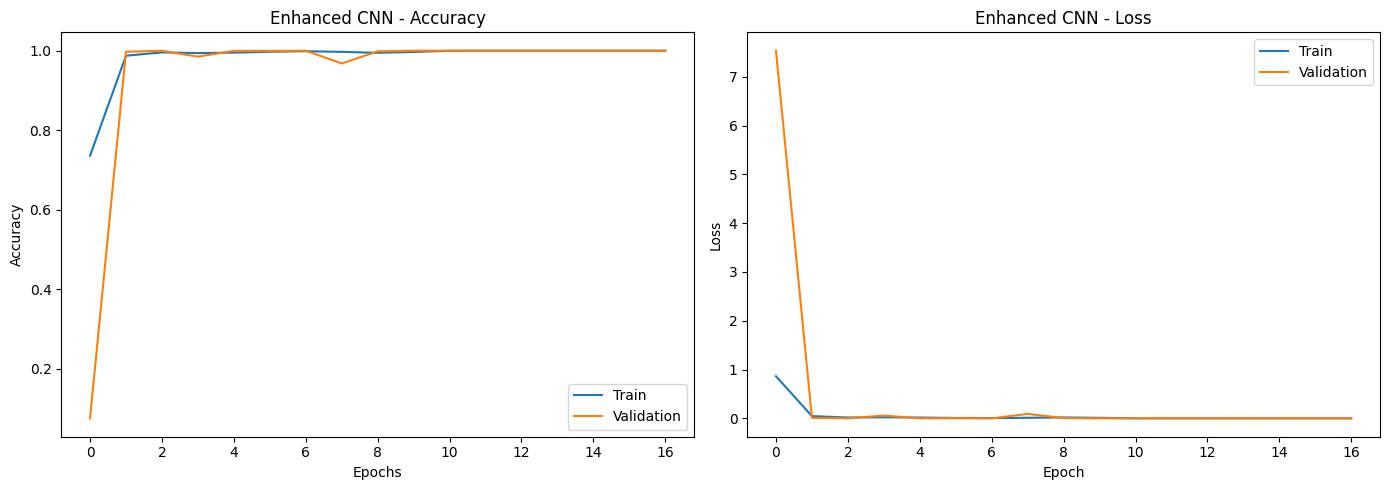

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(history_enhanced.history['accuracy'], label = 'Train')
ax1.plot(history_enhanced.history['val_accuracy'], label = 'Validation')
ax1.set_title('Enhanced CNN - Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_enhanced.history['loss'], label = 'Train')
ax2.plot(history_enhanced.history['val_loss'], label = 'Validation')
ax2.set_title('Enhanced CNN - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [54]:
model_enhanced.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
baseline_loss, baseline_accuracy = model_baseline.evaluate(x_test, y_test, verbose = 0)
enhanced_loss, enhanced_accuracy = model_enhanced.evaluate(x_test, y_test, verbose = 0)

print("Model comparision on test set")
print("==============================")
print(f"Baseline - Accuracy: {baseline_accuracy*100:.2f} | Loss: {baseline_loss:.4f}")
print(f"Enhanced - Accuracy: {enhanced_accuracy*100:.2f} | Loss: {enhanced_loss:.4f}")
print(f"Baseline - Params: {model_baseline.count_params():,}")
print(f"Enhanced - Params: {model_enhanced.count_params():,}")
print(f"Baseline - Time: {baseline_time} seconds")
print(f"Enhanced - Time: {enhanced_time} seconds")

Model comparision on test set
Baseline - Accuracy: 92.72 | Loss: 0.3641
Enhanced - Accuracy: 100.00 | Loss: 0.0013
Baseline - Params: 423,577
Enhanced - Params: 438,585
Baseline - Time: 43 seconds
Enhanced - Time: 81 seconds


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


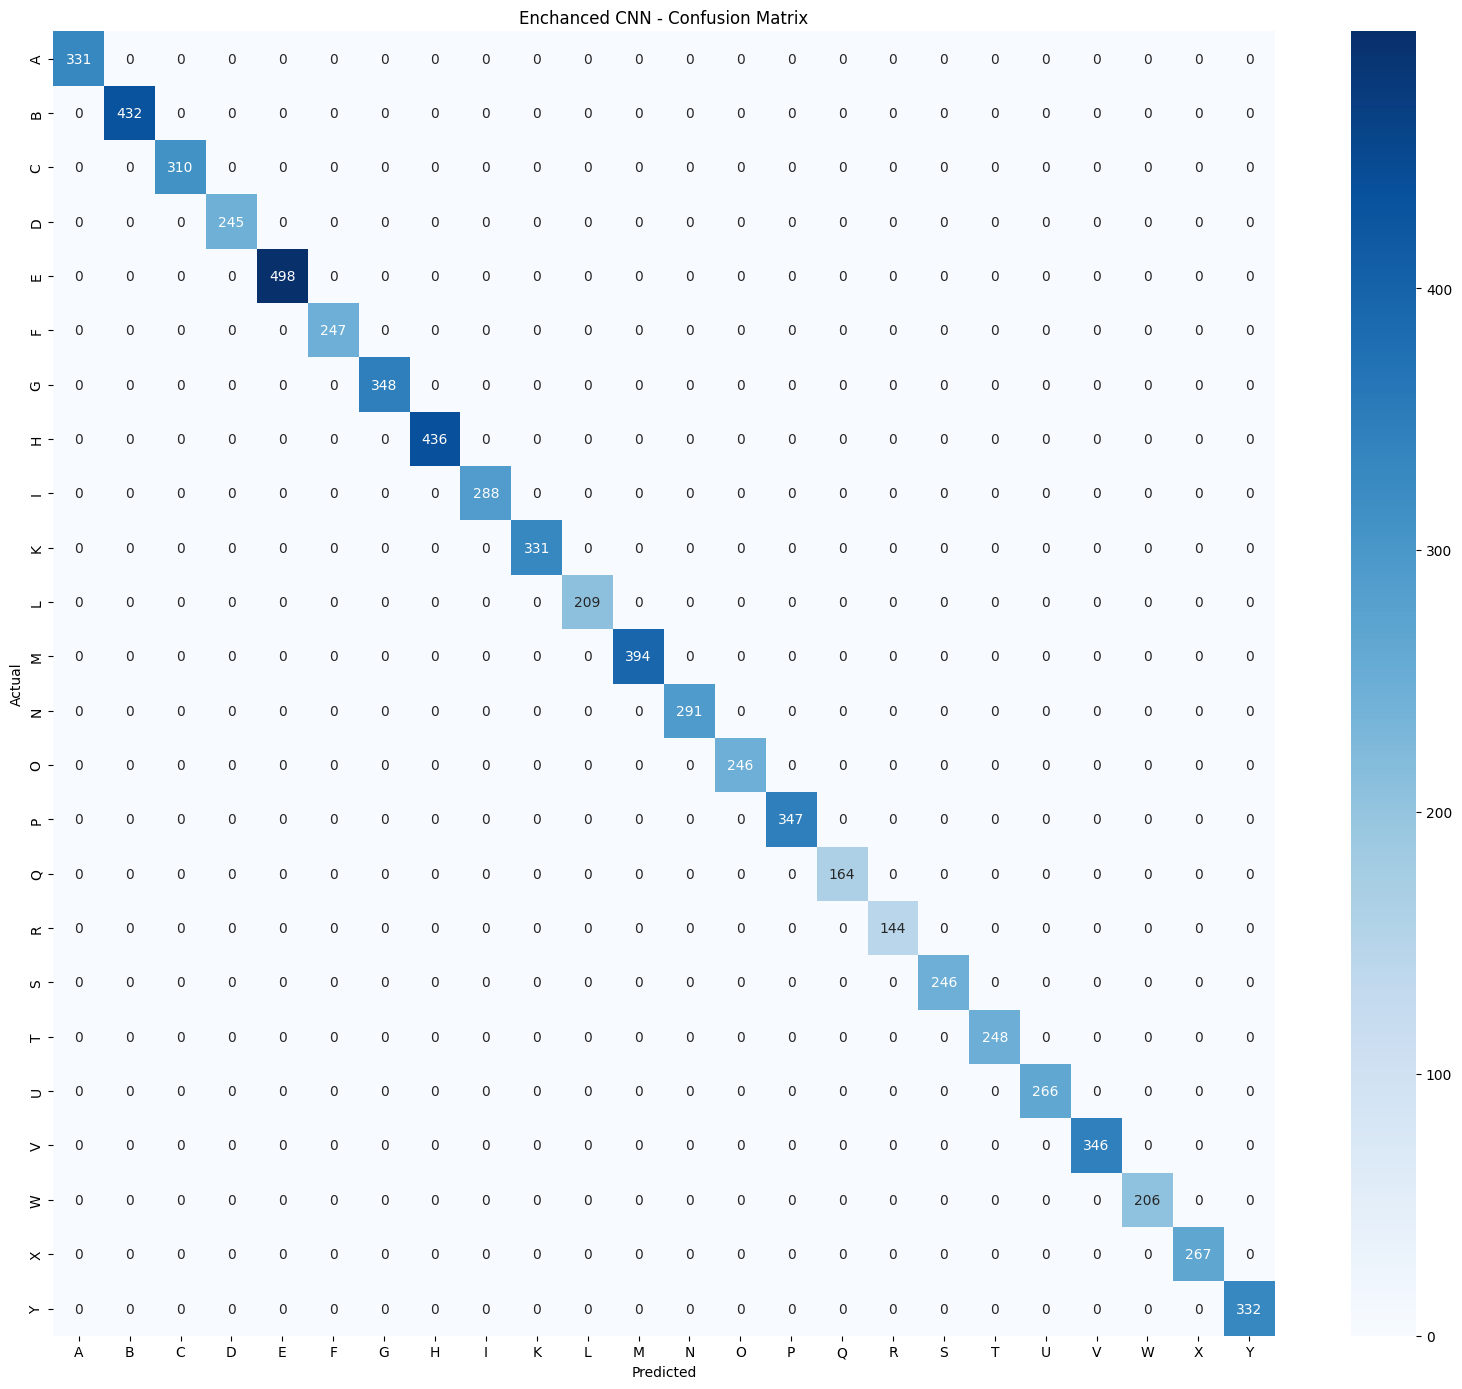

In [55]:
y_pred = model_enhanced.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis = 1)
y_test_classes = np.argmax(y_test, axis = 1)

plt.figure(figsize = (16, 14))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names,
            yticklabels = class_names)
plt.title('Enchanced CNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test_classes, y_pred_classes, target_names = ))